# Gold Layer — Joined & Aggregated Data + EDA

## Retail Banking Environment — Customer Financial Behaviour Analysis

### Context
This notebook is **Part 3 of 3** in our group project medallion pipeline.

- **Part 1 (Bronze)** — Raw mock banking data was generated (customers, accounts, transactions, loan_applications)
- **Part 2 (Silver)** — Data was cleaned, standardized, and validated
- **Part 3 (Gold) — This notebook** — Silver tables are joined and aggregated into analytical Gold tables, then explored through EDA

### What This Notebook Does
1. Load all Silver tables from `sandbox_catalog.banking_details`
2. Create four Gold tables:
   - **`transactions_gold`** — Enriched transaction-level data with customer and account details
   - **`customer_gold`** — Customer-level aggregations with complete financial profile (including most common transaction type)
   - **`transaction_monthly_gold`** — Monthly aggregations by transaction type for seasonal pattern analysis
   - **`loan_approval_demographics_gold`** — Loan approval rates by province and income bracket
3. Perform Exploratory Data Analysis (EDA) with visualizations:
   - KPI summary
   - Transaction patterns by type and category
   - Customer segmentation analysis
   - Loan application insights
   - Age and income distribution
   - Correlation analysis

> **Note:** All Gold tables use the same catalog/schema as Bronze and Silver. The Gold layer is optimized for analytics and reporting.

---
## Imports & Configuration

In [0]:
import logging

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ── Logging setup ──────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("gold")

# ── Plot defaults ──────────────────────────────────────────
plt.rcParams["figure.dpi"]        = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# ── Catalog / schema constants ─────────────────────────────────
CATALOG = "sandbox_catalog"
SCHEMA  = "banking_details"

log.info("Imports complete. Catalog=%s  Schema=%s", CATALOG, SCHEMA)

01:29:08  INFO  Imports complete. Catalog=sandbox_catalog  Schema=banking_details


---
## Helper Functions

In [0]:
def read_table(table_name: str):
    """
    Read a Delta table from the active catalog/schema.
    Returns a Spark DataFrame.
    """
    full_name = f"{CATALOG}.{SCHEMA}.{table_name}"
    df = spark.read.table(full_name)
    log.info("Loaded %s (%d rows)", full_name, df.count())
    return df


def write_table(df, table_name: str, mode: str = "overwrite") -> None:
    """
    Write a Spark DataFrame as a Delta table.
    Uses overwrite mode by default for idempotency.
    """
    full_name = f"{CATALOG}.{SCHEMA}.{table_name}"
    df.write.format("delta").mode(mode).saveAsTable(full_name)
    log.info("Written %s (%d rows)", full_name, df.count())


log.info("Helper functions defined.")

01:29:09  INFO  Helper functions defined.


---
## Gold Layer — Joined & Aggregated Data

We produce four Gold tables:
- **`transactions_gold`** — Enriched transaction-level data with customer demographics and account details
- **`customer_gold`** — Customer-level aggregations with complete financial profile, including most common transaction type
- **`transaction_monthly_gold`** — Monthly transaction volume and counts by transaction type for seasonal analysis
- **`loan_approval_demographics_gold`** — Loan approval rates and average amounts by province and income bracket

### Read Silver Tables

In [0]:
# Reload the Silver tables as the starting point for Gold aggregations
customers_s   = read_table("customers_silver")
accounts_s    = read_table("accounts_silver")
transactions_s = read_table("transactions_silver")
loan_applications_s = read_table("loan_applications_silver")

01:29:11  INFO  Loaded sandbox_catalog.banking_details.customers_silver (1000 rows)
01:29:12  INFO  Loaded sandbox_catalog.banking_details.accounts_silver (1500 rows)
01:29:12  INFO  Loaded sandbox_catalog.banking_details.transactions_silver (9719 rows)
01:29:12  INFO  Loaded sandbox_catalog.banking_details.loan_applications_silver (545 rows)


### Build `transactions_gold`

Enrich transactions with customer demographics and account information.

In [0]:
# Join transactions -> accounts -> customers to build enriched transaction table
# This provides a complete view of each transaction with customer context

transactions_gold = (
    transactions_s
    .join(
        accounts_s.select("account_id", "customer_id", "account_type", 
                          "status", "open_date", "balance"),
        on="account_id",
        how="inner",
    )
    .join(
        customers_s.select("customer_id", "age", "province", 
                           "income_bracket", "join_date"),
        on="customer_id",
        how="inner",
    )
    # Add derived columns for analysis
    .withColumn("transaction_year", F.year("transaction_date"))
    .withColumn("transaction_month", F.month("transaction_date"))
    .withColumn("transaction_quarter", F.quarter("transaction_date"))
    # Calculate days since account opening
    .withColumn("days_since_account_open", 
                F.datediff(F.col("transaction_date"), F.col("open_date")))
    # Customer tenure at time of transaction
    .withColumn("customer_tenure_days",
                F.datediff(F.col("transaction_date"), F.col("join_date")))
)

log.info("transactions_gold built with %d rows", transactions_gold.count())
display(transactions_gold.limit(5))

01:29:15  INFO  transactions_gold built with 9719 rows


customer_id,account_id,transaction_id,transaction_type,transaction_date,amount,merchant_category,account_type,status,open_date,balance,age,province,income_bracket,join_date,transaction_year,transaction_month,transaction_quarter,days_since_account_open,customer_tenure_days
706,583,0,withdrawal,2024-10-26,2344.18,Healthcare,savings,inactive,2023-12-13,292559,53,ON,$75K-$100K,2017-05-26,2024,10,4,318,2710
2,321,1,transfer,2024-12-19,2302.72,null,chequing,inactive,2023-12-13,421674,49,NB,$200K+,2026-02-07,2024,12,4,372,-415
454,310,2,withdrawal,2024-01-29,1912.9,Gas & Transport,savings,active,2023-12-13,715547,43,PE,$200K+,2023-04-18,2024,1,1,47,286
320,269,3,deposit,2024-04-25,355.5,null,chequing,inactive,2023-12-13,372226,49,NL,$50K-$75K,2025-07-27,2024,4,2,134,-458
573,910,4,withdrawal,2024-09-23,4067.81,Dining,savings,closed,2023-12-13,339989,46,QC,$200K+,2025-08-16,2024,9,3,285,-327


### Build `customer_gold`

Aggregate customer-level metrics from transactions, accounts, and loan applications.

In [0]:
# Step 1: Aggregate transaction behavior per customer
transaction_agg = (
    transactions_gold
    .groupBy("customer_id")
    .agg(
        F.count("transaction_id").alias("total_transactions"),
        F.sum("amount").alias("total_transaction_amount"),
        F.avg("amount").alias("avg_transaction_amount"),
        F.max("transaction_date").alias("last_transaction_date"),
        # By transaction type
        F.sum(F.when(F.col("transaction_type") == "deposit", F.col("amount")).otherwise(0)).alias("total_deposits"),
        F.sum(F.when(F.col("transaction_type") == "withdrawal", F.col("amount")).otherwise(0)).alias("total_withdrawals"),
        F.sum(F.when(F.col("transaction_type") == "transfer", F.col("amount")).otherwise(0)).alias("total_transfers"),
        # Count by transaction type
        F.sum(F.when(F.col("transaction_type") == "deposit", 1).otherwise(0)).alias("count_deposits"),
        F.sum(F.when(F.col("transaction_type") == "withdrawal", 1).otherwise(0)).alias("count_withdrawals"),
        F.sum(F.when(F.col("transaction_type") == "transfer", 1).otherwise(0)).alias("count_transfers"),
    )
    .withColumn("total_transaction_amount", F.round("total_transaction_amount", 2))
    .withColumn("avg_transaction_amount", F.round("avg_transaction_amount", 2))
    .withColumn("total_deposits", F.round("total_deposits", 2))
    .withColumn("total_withdrawals", F.round("total_withdrawals", 2))
    .withColumn("total_transfers", F.round("total_transfers", 2))
)

# Step 1b: Find most common transaction type per customer
most_common_type = (
    transactions_gold
    .groupBy("customer_id", "transaction_type")
    .agg(F.count("*").alias("type_count"))
    .withColumn(
        "rank",
        F.row_number().over(
            Window.partitionBy("customer_id").orderBy(F.desc("type_count"))
        )
    )
    .filter(F.col("rank") == 1)
    .select("customer_id", F.col("transaction_type").alias("most_common_transaction_type"))
)

# Join most common type to transaction aggregations
transaction_agg = transaction_agg.join(most_common_type, on="customer_id", how="left")

# Step 2: Aggregate account information per customer
account_agg = (
    accounts_s
    .groupBy("customer_id")
    .agg(
        F.count("account_id").alias("total_accounts"),
        F.sum("balance").alias("total_balance"),
        F.avg("balance").alias("avg_balance"),
        F.sum(F.when(F.col("account_type") == "chequing", 1).otherwise(0)).alias("count_chequing"),
        F.sum(F.when(F.col("account_type") == "savings", 1).otherwise(0)).alias("count_savings"),
        F.sum(F.when(F.col("status") == "active", 1).otherwise(0)).alias("active_accounts"),
    )
    .withColumn("total_balance", F.round("total_balance", 2))
    .withColumn("avg_balance", F.round("avg_balance", 2))
)

# Step 3: Aggregate loan information per customer
loan_agg = (
    loan_applications_s
    .groupBy("customer_id")
    .agg(
        F.count("application_id").alias("total_loan_applications"),
        F.sum("amount_requested").alias("total_amount_requested"),
        F.avg("interest_rate").alias("avg_interest_rate"),
        F.sum(F.when(F.col("status") == "approved", 1).otherwise(0)).alias("approved_loans"),
        F.sum(F.when(F.col("status") == "denied", 1).otherwise(0)).alias("denied_loans"),
        F.sum(F.when(F.col("status") == "pending", 1).otherwise(0)).alias("pending_loans"),
    )
    .withColumn("total_amount_requested", F.round("total_amount_requested", 2))
    .withColumn("avg_interest_rate", F.round("avg_interest_rate", 2))
)

# Step 4: Join everything together with customer demographics
customer_gold = (
    customers_s
    .join(transaction_agg, on="customer_id", how="left")
    .join(account_agg, on="customer_id", how="left")
    .join(loan_agg, on="customer_id", how="left")
    # Fill nulls for customers with no transactions/accounts/loans
    .fillna(0, subset=[
        "total_transactions", "total_transaction_amount", "avg_transaction_amount",
        "total_deposits", "total_withdrawals", "total_transfers",
        "count_deposits", "count_withdrawals", "count_transfers",
        "total_accounts", "total_balance", "avg_balance",
        "count_chequing", "count_savings", "active_accounts",
        "total_loan_applications", "total_amount_requested", "avg_interest_rate",
        "approved_loans", "denied_loans", "pending_loans",
    ])
    # Add customer segmentation based on transaction volume
    .withColumn(
        "customer_segment",
        F.when(F.col("total_transaction_amount") >= 100000, F.lit("High Value"))
        .when(F.col("total_transaction_amount") >= 50000, F.lit("Medium Value"))
        .when(F.col("total_transaction_amount") >= 10000, F.lit("Low Value"))
        .otherwise(F.lit("Inactive"))
    )
)

log.info("customer_gold built with %d rows", customer_gold.count())
display(customer_gold.limit(5))

01:29:26  INFO  customer_gold built with 1000 rows


customer_id,age,province,income_bracket,join_date,total_transactions,total_transaction_amount,avg_transaction_amount,last_transaction_date,total_deposits,total_withdrawals,total_transfers,count_deposits,count_withdrawals,count_transfers,most_common_transaction_type,total_accounts,total_balance,avg_balance,count_chequing,count_savings,active_accounts,total_loan_applications,total_amount_requested,avg_interest_rate,approved_loans,denied_loans,pending_loans,customer_segment
0,26,PE,$75K-$100K,2022-06-11,0,0.0,0.0,null,0.0,0.0,0.0,0,0,0,null,0,0,0.0,0,0,0,2,96674.64,14.17,1,1,0,Inactive
1,42,NB,$25K-$50K,2024-08-09,13,30905.22,2377.32,2024-11-26,8420.75,10543.52,11940.95,4,5,4,withdrawal,1,870078,870078.0,0,1,1,0,0.0,0.0,0,0,0,Low Value
2,49,NB,$200K+,2026-02-07,16,34644.63,2165.29,2024-12-19,8959.77,23293.28,2391.58,3,11,2,withdrawal,2,1334605,667302.5,1,1,0,1,43134.87,13.98,1,0,0,Low Value
3,65,NB,$100K-$150K,2016-05-17,9,22017.54,2446.39,2024-11-02,4216.24,13241.53,4559.77,2,6,1,withdrawal,3,1923612,641204.0,2,1,0,1,54654.23,11.68,0,1,0,Low Value
4,40,MB,$25K-$50K,2025-03-03,7,13637.27,1948.18,2024-11-07,4816.53,3813.05,5007.69,3,2,2,deposit,1,498824,498824.0,1,0,0,0,0.0,0.0,0,0,0,Low Value


### Write Gold Tables

In [0]:
write_table(transactions_gold, "transactions_gold")

# Write customer_gold with schema overwrite to include new column
customer_gold.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(f"{CATALOG}.{SCHEMA}.customer_gold")
log.info("Written %s.%s.customer_gold (%d rows)", CATALOG, SCHEMA, customer_gold.count())

log.info("Core Gold tables written successfully.")
log.info("Additional aggregation tables will be created in following cells.")

01:29:34  INFO  Written sandbox_catalog.banking_details.transactions_gold (9719 rows)
01:29:44  INFO  Written sandbox_catalog.banking_details.customer_gold (1000 rows)
01:29:44  INFO  Core Gold tables written successfully.
01:29:44  INFO  Additional aggregation tables will be created in following cells.


### Build `transaction_monthly_gold`

Aggregate transactions by month and type for seasonal pattern analysis.

In [0]:
# Aggregate transactions by year-month and transaction type
# This allows analysis of seasonal patterns and trends by transaction type

transaction_monthly_gold = (
    transactions_gold
    .withColumn("year_month", 
                F.date_format(F.col("transaction_date"), "yyyy-MM"))
    .groupBy("year_month", "transaction_type")
    .agg(
        F.sum("amount").alias("total_volume"),
        F.count("transaction_id").alias("transaction_count"),
        F.avg("amount").alias("avg_amount"),
    )
    .withColumn("total_volume", F.round("total_volume", 2))
    .withColumn("avg_amount", F.round("avg_amount", 2))
    .orderBy("year_month", "transaction_type")
)

log.info("transaction_monthly_gold built with %d rows", transaction_monthly_gold.count())
display(transaction_monthly_gold.limit(10))

01:29:45  INFO  transaction_monthly_gold built with 36 rows


year_month,transaction_type,total_volume,transaction_count,avg_amount
2024-01,deposit,652437.85,259,2519.07
2024-01,transfer,370455.83,137,2704.06
2024-01,withdrawal,1002676.43,434,2310.31
2024-02,deposit,564451.41,222,2542.57
2024-02,transfer,321335.73,140,2295.26
2024-02,withdrawal,922698.0,385,2396.62
2024-03,deposit,617540.12,242,2551.82
2024-03,transfer,406319.76,168,2418.57
2024-03,withdrawal,1043678.13,427,2444.21
2024-04,deposit,620463.6,259,2395.61


In [0]:
write_table(transaction_monthly_gold, "transaction_monthly_gold")
log.info("transaction_monthly_gold written successfully.")

01:29:51  INFO  Written sandbox_catalog.banking_details.transaction_monthly_gold (36 rows)
01:29:51  INFO  transaction_monthly_gold written successfully.


### Build `loan_approval_demographics_gold`

Analyze loan approval rates by province and income bracket.

In [0]:
# Join loan applications with customer demographics to analyze approval patterns

# First, join loan applications with customers to get demographics
loan_with_demographics = (
    loan_applications_s
    .join(
        customers_s.select("customer_id", "province", "income_bracket"),
        on="customer_id",
        how="inner"
    )
)

# Aggregate by province
loan_approval_by_province = (
    loan_with_demographics
    .groupBy("province")
    .agg(
        F.count("application_id").alias("total_applications"),
        F.sum(F.when(F.col("status") == "approved", 1).otherwise(0)).alias("approved_count"),
        F.sum(F.when(F.col("status") == "denied", 1).otherwise(0)).alias("denied_count"),
        F.avg("amount_requested").alias("avg_amount_requested"),
        F.avg(F.when(F.col("status") == "approved", F.col("amount_requested")).otherwise(None)).alias("avg_amount_approved"),
    )
    .withColumn(
        "approval_rate",
        F.round((F.col("approved_count") / F.col("total_applications")) * 100, 2)
    )
    .withColumn("avg_amount_requested", F.round("avg_amount_requested", 2))
    .withColumn("avg_amount_approved", F.round("avg_amount_approved", 2))
    .withColumn("dimension", F.lit("province"))
    .withColumnRenamed("province", "dimension_value")
)

# Aggregate by income bracket
loan_approval_by_income = (
    loan_with_demographics
    .groupBy("income_bracket")
    .agg(
        F.count("application_id").alias("total_applications"),
        F.sum(F.when(F.col("status") == "approved", 1).otherwise(0)).alias("approved_count"),
        F.sum(F.when(F.col("status") == "denied", 1).otherwise(0)).alias("denied_count"),
        F.avg("amount_requested").alias("avg_amount_requested"),
        F.avg(F.when(F.col("status") == "approved", F.col("amount_requested")).otherwise(None)).alias("avg_amount_approved"),
    )
    .withColumn(
        "approval_rate",
        F.round((F.col("approved_count") / F.col("total_applications")) * 100, 2)
    )
    .withColumn("avg_amount_requested", F.round("avg_amount_requested", 2))
    .withColumn("avg_amount_approved", F.round("avg_amount_approved", 2))
    .withColumn("dimension", F.lit("income_bracket"))
    .withColumnRenamed("income_bracket", "dimension_value")
)

# Union both aggregations into a single gold table
loan_approval_demographics_gold = loan_approval_by_province.union(loan_approval_by_income)

log.info("loan_approval_demographics_gold built with %d rows", loan_approval_demographics_gold.count())
display(loan_approval_demographics_gold)

01:29:52  INFO  loan_approval_demographics_gold built with 17 rows


dimension_value,total_applications,approved_count,denied_count,avg_amount_requested,avg_amount_approved,approval_rate,dimension
MB,54,25,24,227775.57,239166.19,46.3,province
AB,59,28,20,164237.0,212515.4,47.46,province
NS,51,29,12,280292.65,354886.83,56.86,province
NB,43,26,13,183509.63,133326.75,60.47,province
NL,57,34,16,169240.23,175179.27,59.65,province
BC,52,29,15,135103.73,161917.45,55.77,province
QC,53,26,17,185104.04,160763.99,49.06,province
SK,59,28,19,179443.06,183789.91,47.46,province
ON,59,31,19,215473.19,182217.49,52.54,province
PE,58,33,20,210428.59,232408.94,56.9,province


In [0]:
write_table(loan_approval_demographics_gold, "loan_approval_demographics_gold")
log.info("loan_approval_demographics_gold written successfully.")

01:29:58  INFO  Written sandbox_catalog.banking_details.loan_approval_demographics_gold (17 rows)
01:29:58  INFO  loan_approval_demographics_gold written successfully.


---
## Exploratory Data Analysis (EDA)

### Load Gold Tables

In [0]:
# Load Gold tables and convert to Pandas for plotting.
# Gold tables are aggregated and small enough to fit comfortably in driver memory.

transactions_df = read_table("transactions_gold").toPandas()
customer_df = read_table("customer_gold").toPandas()

log.info("Gold tables loaded -- transactions: %d rows, customer: %d rows",
         len(transactions_df), len(customer_df))

01:30:00  INFO  Loaded sandbox_catalog.banking_details.transactions_gold (9719 rows)
01:30:01  INFO  Loaded sandbox_catalog.banking_details.customer_gold (1000 rows)
01:30:02  INFO  Gold tables loaded -- transactions: 9719 rows, customer: 1000 rows


### Summary Statistics

In [0]:
# Descriptive statistics for key numeric columns in each Gold table

print("=== transactions_gold -- Key Metrics ===")
print(transactions_df[["amount", "balance", "age", 
                       "days_since_account_open"]].describe().round(2))

print("\n=== customer_gold -- Key Metrics ===")
print(customer_df[["age", "total_transactions", "total_transaction_amount",
                   "total_balance", "total_accounts"]].describe().round(2))

=== transactions_gold -- Key Metrics ===
        amount    balance      age  days_since_account_open
count  9719.00    9719.00  9719.00                  9719.00
mean   2455.66  477619.31    44.30                   200.55
std    1472.66  289206.69    15.19                   105.44
min       1.20    1241.00    18.00                    19.00
25%    1154.84  220154.00    31.00                   110.00
50%    2434.36  475510.00    45.00                   199.00
75%    3736.96  718785.00    57.00                   291.00
max    4999.08  999430.00    70.00                   384.00

=== customer_gold -- Key Metrics ===
           age  total_transactions  ...  total_balance  total_accounts
count  1000.00             1000.00  ...        1000.00          1000.0
mean     44.34                9.72  ...      730198.83             1.5
std      15.47                9.86  ...      701260.37             1.2
min      18.00                0.00  ...           0.00             0.0
25%      31.00            

### KPI Summary

In [0]:
# Compute and display top-level business KPIs

total_customers = customer_df["customer_id"].nunique()
total_accounts = customer_df["total_accounts"].sum()
total_transaction_volume = transactions_df["amount"].sum()
total_transactions = len(transactions_df)
avg_transaction_amount = transactions_df["amount"].mean()
total_balance = customer_df["total_balance"].sum()
avg_balance_per_customer = customer_df["total_balance"].mean()

# Loan metrics
total_loan_applications = customer_df["total_loan_applications"].sum()
approved_loans = customer_df["approved_loans"].sum()
approval_rate = (approved_loans / total_loan_applications * 100) if total_loan_applications > 0 else 0

print("="*60)
print("  BANKING KPI SUMMARY")
print("="*60)
print(f"Total Customers:           {total_customers:>12,}")
print(f"Total Accounts:            {int(total_accounts):>12,}")
print(f"Total Transactions:        {total_transactions:>12,}")
print(f"Total Transaction Volume:  ${total_transaction_volume:>12,.2f}")
print(f"Avg Transaction Amount:    ${avg_transaction_amount:>12,.2f}")
print(f"Total Customer Balance:    ${total_balance:>12,.2f}")
print(f"Avg Balance per Customer:  ${avg_balance_per_customer:>12,.2f}")
print(f"Total Loan Applications:   {int(total_loan_applications):>12,}")
print(f"Loan Approval Rate:        {approval_rate:>12.1f}%")
print("="*60)

  BANKING KPI SUMMARY
Total Customers:                  1,000
Total Accounts:                   1,500
Total Transactions:               9,719
Total Transaction Volume:  $23,866,557.78
Avg Transaction Amount:    $    2,455.66
Total Customer Balance:    $730,198,826.00
Avg Balance per Customer:  $  730,198.83
Total Loan Applications:            545
Loan Approval Rate:                53.0%


### Transaction Volume by Type

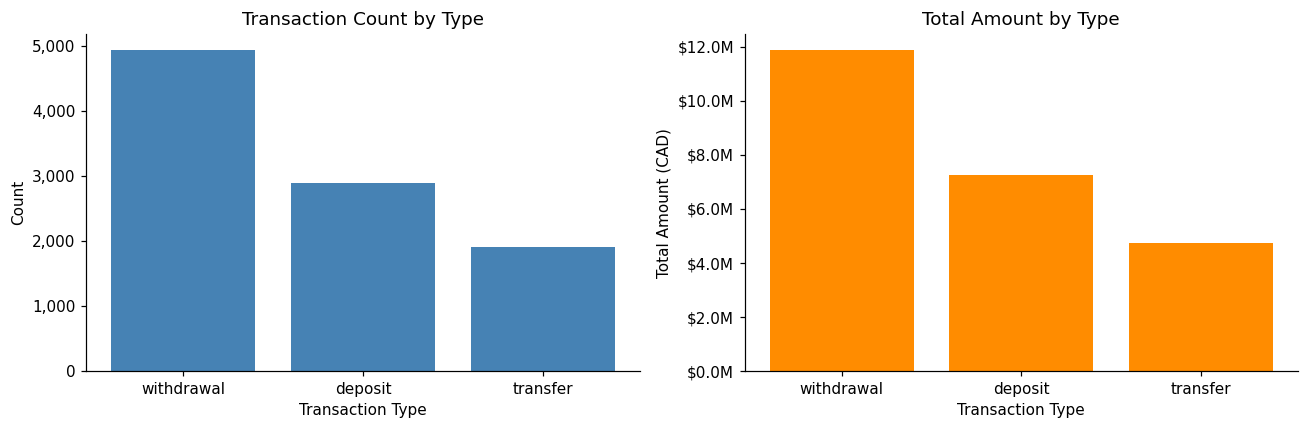

In [0]:
# Grouped bar chart: compare transaction count and total amount by type

type_summary = (
    transactions_df.groupby("transaction_type")[["amount"]]
    .agg(["count", "sum"])
    .reset_index()
)
type_summary.columns = ["transaction_type", "count", "total_amount"]
type_summary = type_summary.sort_values("total_amount", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Transaction count
ax1.bar(type_summary["transaction_type"], type_summary["count"], color="steelblue")
ax1.set_title("Transaction Count by Type")
ax1.set_xlabel("Transaction Type")
ax1.set_ylabel("Count")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Total amount
ax2.bar(type_summary["transaction_type"], type_summary["total_amount"], color="darkorange")
ax2.set_title("Total Amount by Type")
ax2.set_xlabel("Transaction Type")
ax2.set_ylabel("Total Amount (CAD)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))

plt.tight_layout()
plt.show()

### Monthly Transaction Trend

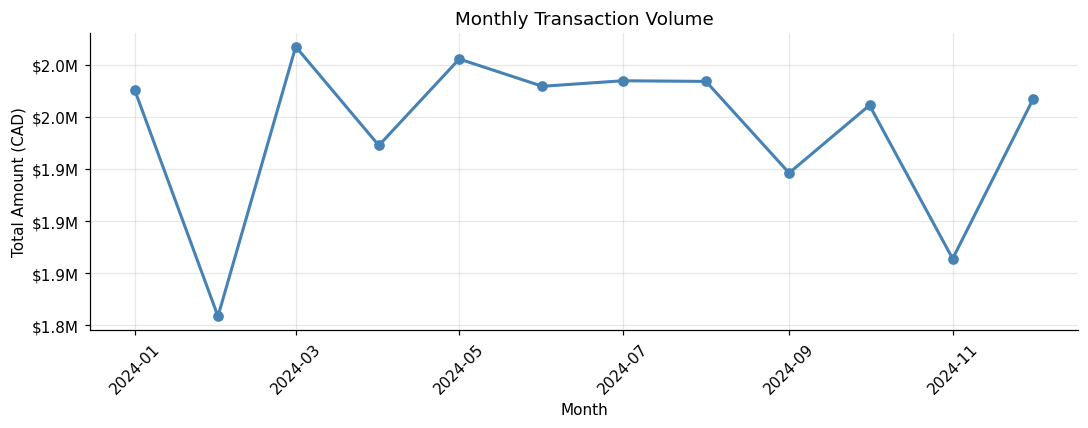

In [0]:
# Line chart: transaction volume by month to reveal trends

transactions_df["year_month"] = pd.to_datetime(
    transactions_df["transaction_year"].astype(str) + "-" + 
    transactions_df["transaction_month"].astype(str).str.zfill(2) + "-01"
)

monthly_trend = (
    transactions_df.groupby("year_month")["amount"]
    .agg(["count", "sum"])
    .sort_index()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_trend["year_month"], monthly_trend["sum"], 
        marker="o", linewidth=2, color="steelblue")
ax.set_title("Monthly Transaction Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount (CAD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Segment Distribution

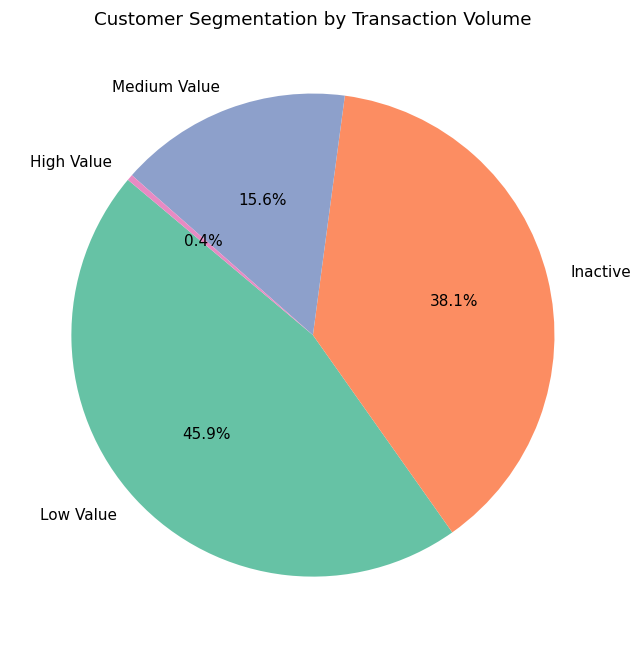

In [0]:
# Pie chart: proportion of customers in each segment

segment_dist = customer_df["customer_segment"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(
    segment_dist,
    labels=segment_dist.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set2.colors,
)
ax.set_title("Customer Segmentation by Transaction Volume")
plt.tight_layout()
plt.show()

### Distribution of Customer Age

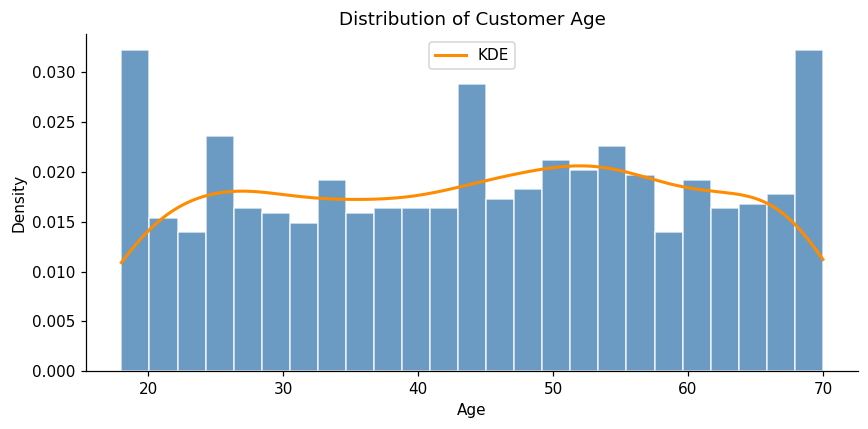

In [0]:
# Histogram with a KDE overlay: understand customer age distribution

ages = customer_df["age"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=25, color="steelblue", edgecolor="white", alpha=0.8, density=True)

# Overlay a smooth KDE curve
kde     = gaussian_kde(ages)
x_range = np.linspace(ages.min(), ages.max(), 200)
ax.plot(x_range, kde(x_range), color="darkorange", linewidth=2, label="KDE")

ax.set_title("Distribution of Customer Age")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

### Transaction Amount by Income Bracket

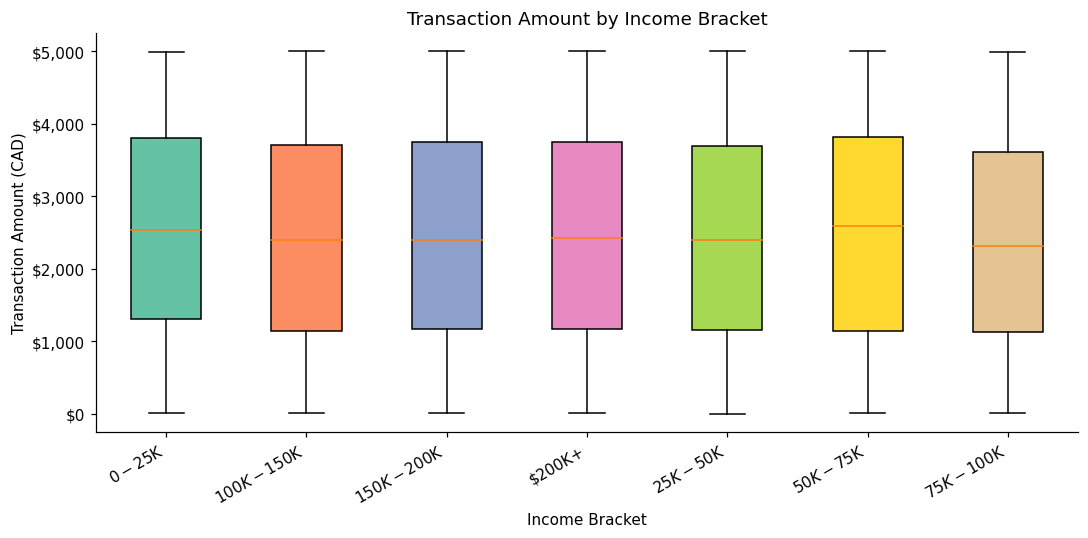

In [0]:
# Box plot: transaction amount distribution across income brackets

income_brackets = transactions_df["income_bracket"].unique()
income_order = sorted(income_brackets, key=lambda x: x)  # Simple alphabetical sort

data_by_income = [
    transactions_df.loc[transactions_df["income_bracket"] == ib, "amount"].dropna().values
    for ib in income_order
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_income, labels=income_order, patch_artist=True)
for patch, color in zip(bp["boxes"], plt.cm.Set2.colors):
    patch.set_facecolor(color)

ax.set_title("Transaction Amount by Income Bracket")
ax.set_xlabel("Income Bracket")
ax.set_ylabel("Transaction Amount (CAD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Loan Approval Rate by Loan Type

01:30:06  INFO  Loaded sandbox_catalog.banking_details.loan_applications_silver (545 rows)


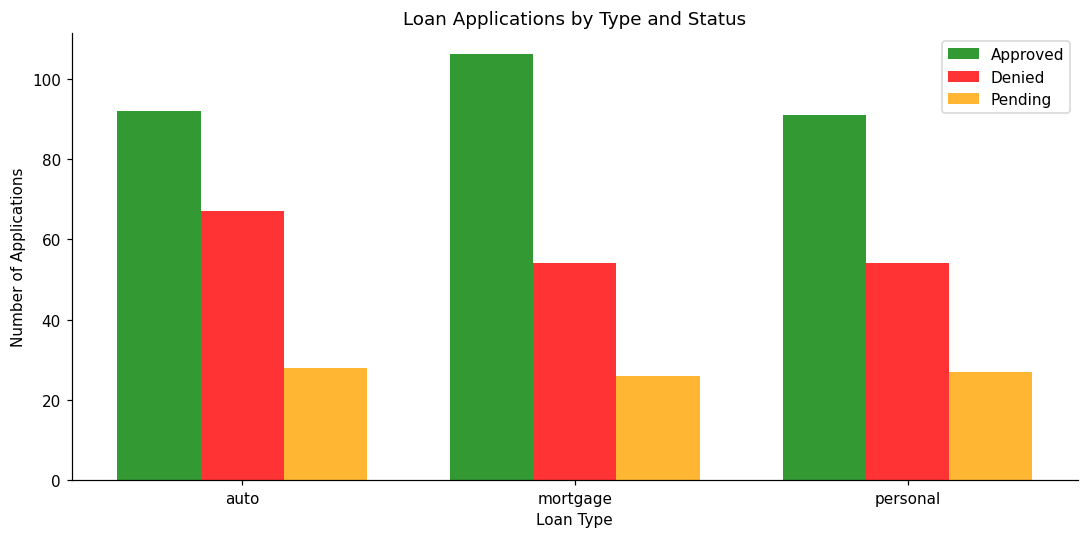

In [0]:
# Grouped bar chart: compare approval rates across loan types

# Filter customers who applied for loans
loan_customers = customer_df[customer_df["total_loan_applications"] > 0].copy()

if len(loan_customers) > 0:
    # We need to go back to the loan_applications table to get loan_type
    loan_apps = read_table("loan_applications_silver").toPandas()
    
    loan_summary = (
        loan_apps.groupby(["loan_type", "status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Calculate approval rate
    if "approved" in loan_summary.columns and "denied" in loan_summary.columns:
        loan_summary["approval_rate"] = (
            loan_summary["approved"] / 
            (loan_summary["approved"] + loan_summary["denied"]) * 100
        )
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(loan_summary))
    width = 0.25
    
    if "approved" in loan_summary.columns:
        ax.bar(x - width, loan_summary["approved"], width, label="Approved", color="green", alpha=0.8)
    if "denied" in loan_summary.columns:
        ax.bar(x, loan_summary["denied"], width, label="Denied", color="red", alpha=0.8)
    if "pending" in loan_summary.columns:
        ax.bar(x + width, loan_summary["pending"], width, label="Pending", color="orange", alpha=0.8)
    
    ax.set_title("Loan Applications by Type and Status")
    ax.set_xlabel("Loan Type")
    ax.set_ylabel("Number of Applications")
    ax.set_xticks(x)
    ax.set_xticklabels(loan_summary["loan_type"])
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No loan application data available for visualization.")

### Top 10 Customers by Total Transaction Amount

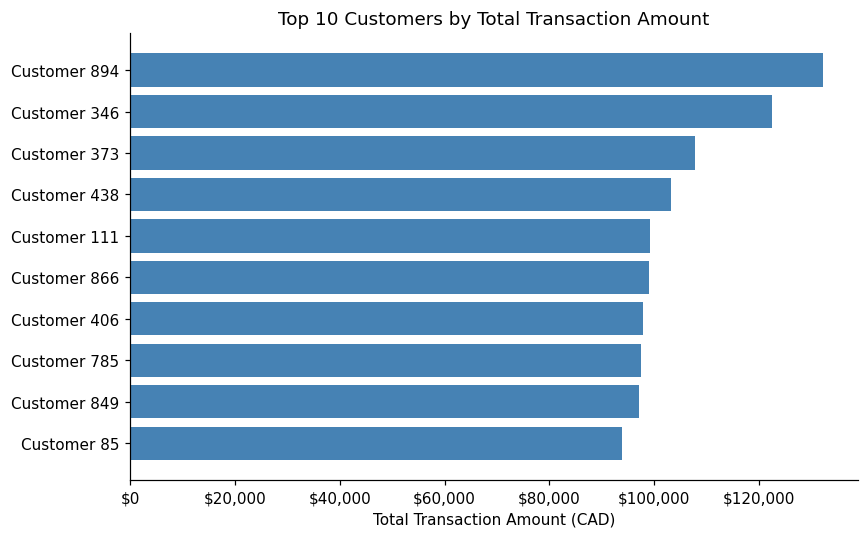

In [0]:
# Horizontal bar chart: identify highest-value customers

top10 = (
    customer_df[["customer_id", "total_transaction_amount"]]
    .sort_values("total_transaction_amount", ascending=False)
    .head(10)
)

# Create customer labels
top10["customer_label"] = top10["customer_id"].apply(lambda x: f"Customer {x}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["customer_label"], top10["total_transaction_amount"], color="steelblue")
ax.invert_yaxis()   # highest value at the top
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_title("Top 10 Customers by Total Transaction Amount")
ax.set_xlabel("Total Transaction Amount (CAD)")
plt.tight_layout()
plt.show()

### Customer Distribution by Province

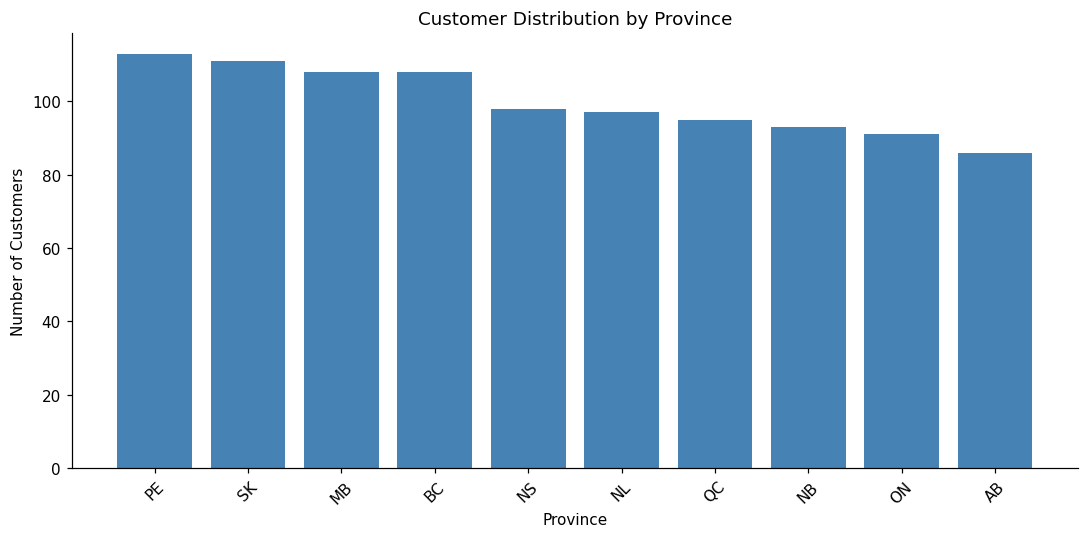

In [0]:
# Bar chart: customer count by province

province_dist = customer_df["province"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(province_dist.index, province_dist.values, color="steelblue")
ax.set_title("Customer Distribution by Province")
ax.set_xlabel("Province")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap — Customer Metrics

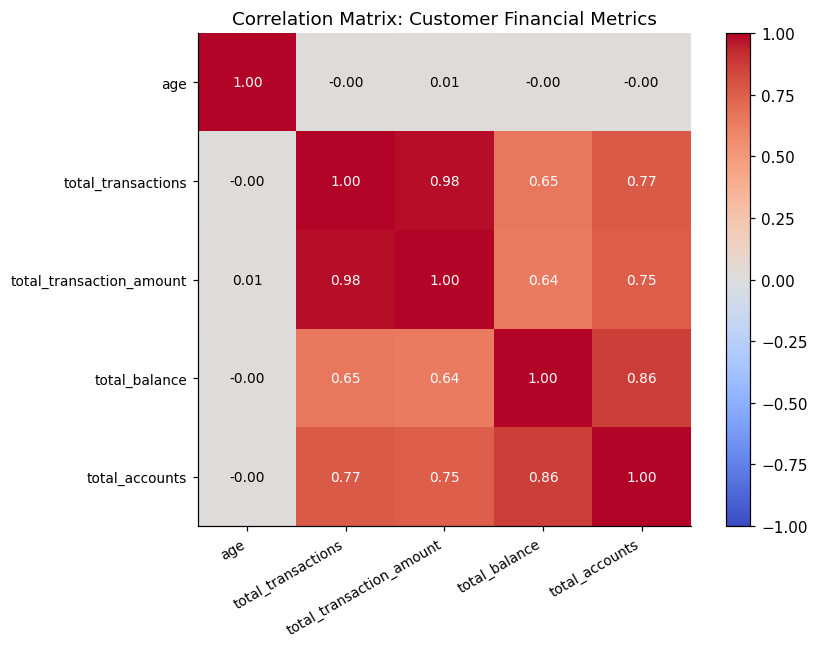

In [0]:
# Heatmap: visualize linear relationships between customer-level metrics

corr_cols = [
    "age", "total_transactions", "total_transaction_amount", 
    "total_balance", "total_accounts"
]
corr_matrix = customer_df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotate each cell with its correlation value
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

ax.set_title("Correlation Matrix: Customer Financial Metrics")
plt.tight_layout()
plt.show()